In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

### Read Decision Forests Results

In [16]:
Ts_DF = [0]+[2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
Ts_DF_final = [0,128,256, 512, 750, 1024, 1250, 1500, 2048]
step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/DF/RF_oh_w_time0_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_DF):
        if T not in Ts_DF_final:
            pass
        else:
            irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
            preward = compute_normalized_future_rewards(irewards,100,0.5)
            path, ireward_opt = path_opt(states[k,0], T, 100)
            preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
            prewards.append(np.sum(preward).item())
            pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_arr.shape)

#PREWARDS = []
#PREGRETS = []
#for rep in range(10):
#    fn = f"../results/PAFM/DF/RF_optimal_oh_w_time128_2048_lookahead{step}_reps{rep}.npz"
#    data = np.load(fn)
#    states = data["future_states"]
#    prewards = []
#    pregrets = []
#    for k,T in enumerate(Ts_DF):
#        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
#        preward = compute_normalized_future_rewards(irewards,100,0.5)
#        path, ireward_opt = path_opt(states[k,0], T, 100)
#        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
#        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
#        prewards.append(np.sum(preward).item())
#        pregrets.append(pregret)
#    PREWARDS.append(prewards)
#    PREGRETS.append(pregrets)
#    PREWARDS_arr = np.vstack(PREWARDS)
#    PREGRETS_PAFM_DF_opt_arr = np.vstack(PREGRETS)
#print(PREGRETS_PAFM_DF_opt_arr.shape)
# PREGRETS_PAFM_DF_arr

(10, 9)


### Read Neural Net Results

In [17]:
Ts_NN = [0,128,256,512]+[750]+[1024,1250,1500,2048]

step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/NN/NN_onehot_w_lookahead_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_NN):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_NN_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_NN_arr.shape)

#PREWARDS = []
#PREGRETS = []
#for rep in range(1):
#    fn = f"../results/PAFM/NN/NN_oracle_w_lookahead_PAFM.npz"
#    data = np.load(fn)
#    states = data["future_states"]
#    prewards = []
#    pregrets = []
#    for k,T in enumerate(Ts_NN):
#        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
#        preward = compute_normalized_future_rewards(irewards,100,0.5)
#        path, ireward_opt = path_opt(states[k,0], T, 100)
#        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
#        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
#        prewards.append(np.sum(preward).item())
#        pregrets.append(pregret)
#    PREWARDS.append(prewards)
#    PREGRETS.append(pregrets)
#    PREWARDS_arr = np.vstack(PREWARDS)
#    PREGRETS_PAFM_NN_opt_arr = np.vstack(PREGRETS)
#print(PREGRETS_PAFM_NN_opt_arr.shape)
# PREGRETS_PAFM_DF_arr

(10, 9)


# Read RL baseline

In [6]:
fn = f"../results/RL/pregret_fqi_notime.npz"
data = np.load(fn)
data['pregret_list']

array([1.02055431, 1.2008456 , 1.18411001, 1.18927797, 1.19613473,
       1.18778069, 1.1278969 , 1.18778069])

In [7]:
# Load offline FQI data
fn = f"../results/RL/offline_pregrets_fqi.npz"
data = np.load(fn)
PREGRETS_FQI_notime = data["pregret_list_notime"]
PREGRETS_FQI_time = data["pregret_list_time"]
Ts_RL_offline = data["t_list"]
print(f"Offline FQI data loaded: {PREGRETS_FQI_notime.shape} reps x time points")
print(f"Time points: {Ts_RL_offline}")
print(f"FQI notime data shape: {PREGRETS_FQI_notime.shape}")
print(f"FQI time data shape: {PREGRETS_FQI_time.shape}")

# Check if T=0 exists and handle it for log plotting
if Ts_RL_offline[0] == 0:
    print("Found T=0 in data - need to handle for log scale")
    # For log plotting, we'll need to either exclude T=0 or replace it with a small value
    Ts_RL_offline_log = Ts_RL_offline.copy()
    Ts_RL_offline_log[0] = 1  # Replace 0 with 1 for log plotting
    print(f"Modified time points for log scale: {Ts_RL_offline_log}")
else:
    Ts_RL_offline_log = Ts_RL_offline
    print("No T=0 found, using original time points")

# Load original FQI data for comparison
PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_fqi_notime.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_FQI_notime_orig = np.vstack(PREGRETS)

PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_fqi_time.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_FQI_time_orig = np.vstack(PREGRETS)


PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_harmonic_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_hmn_time = np.vstack(PREGRETS)


PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_known_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_period = np.vstack(PREGRETS)

PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_unknown_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_time = np.vstack(PREGRETS)

PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_notime.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_notime = np.vstack(PREGRETS)

Offline FQI data loaded: (10, 8) reps x time points
Time points: [    0   128   512  1024  2048  4096 10000 20000]
FQI notime data shape: (10, 8)
FQI time data shape: (10, 8)
Found T=0 in data - need to handle for log scale
Modified time points for log scale: [    1   128   512  1024  2048  4096 10000 20000]


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_28934/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


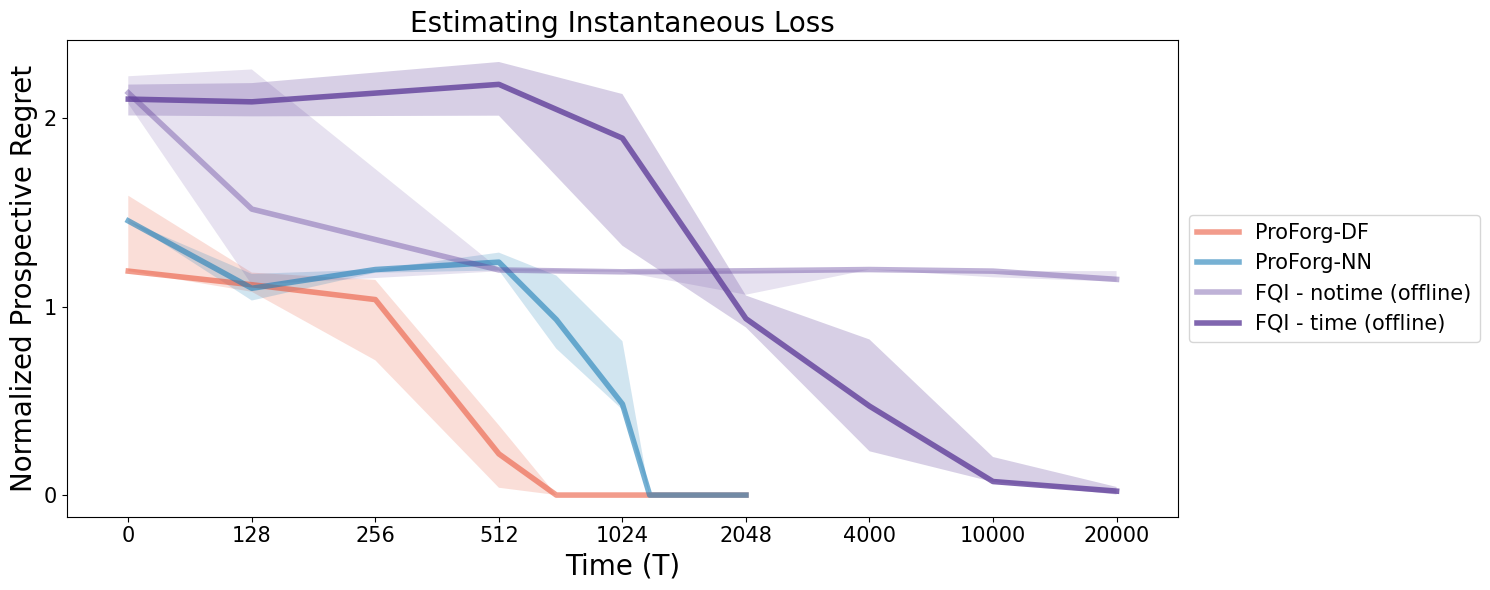

In [20]:
plt.figure(figsize=(15, 6))
linewidth = 4
fontsize = 20

pafm_df, pafm_df_opt = get_close_colors("OrRd", start = 0.65, delta = 0.3, n = 2) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi,_ = get_close_colors("Purples", start=0.8, delta=0.5,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {"PAFM_oh_RF": pafm_df,
          "PAFM_opt_RF":pafm_df,
          "PAFM_oh_NN": pafm_nn,
          "PAFM_opt_NN":pafm_nn,
          "RL_FQI":rl_fqi,
          "RL_TQL":rl_tql
          }

# Create custom transformation for even spacing
target_times = [0, 128, 256, 512, 1024, 2048, 4096, 10000, 20000]
target_positions = np.arange(len(target_times))  # [0, 1, 2, 3, 4, 5, 6, 7, 8]

def transform_time_to_position(times, target_times, target_positions):
    """Transform actual time values to evenly spaced positions"""
    transformed = np.zeros_like(times, dtype=float)
    
    for i, t in enumerate(times):
        if t in target_times:
            # Exact match
            transformed[i] = target_positions[target_times.index(t)]
        else:
            # Interpolate between nearest target times
            target_array = np.array(target_times)
            if t < target_times[0]:
                transformed[i] = target_positions[0]
            elif t > target_times[-1]:
                transformed[i] = target_positions[-1]
            else:
                # Find bracketing indices
                lower_idx = np.where(target_array <= t)[0][-1]
                upper_idx = np.where(target_array >= t)[0][0]
                
                if lower_idx == upper_idx:
                    transformed[i] = target_positions[lower_idx]
                else:
                    # Linear interpolation in position space
                    t_lower, t_upper = target_times[lower_idx], target_times[upper_idx]
                    pos_lower, pos_upper = target_positions[lower_idx], target_positions[upper_idx]
                    
                    # Interpolate
                    if t_upper == t_lower:
                        transformed[i] = pos_lower
                    else:
                        weight = (t - t_lower) / (t_upper - t_lower)
                        transformed[i] = pos_lower + weight * (pos_upper - pos_lower)
    
    return transformed

# Transform all time series to evenly spaced positions
Ts_DF_transformed = transform_time_to_position(Ts_DF_final, target_times, target_positions)
Ts_NN_transformed = transform_time_to_position(Ts_NN, target_times, target_positions)
Ts_RL_transformed = transform_time_to_position(Ts_RL_offline, target_times, target_positions)

## Plot DF with transformed positions
median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
plt.plot(Ts_DF_transformed, median,color=colors["PAFM_oh_RF"], lw = linewidth,alpha = 0.6,label = 'ProForg-DF')
plt.fill_between(Ts_DF_transformed, q25, q75, color=colors["PAFM_oh_RF"], alpha=0.20, edgecolor="none")

## Plot NN with transformed positions
median = np.median(PREGRETS_PAFM_NN_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_NN_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_NN_arr, 75, axis=0)
plt.plot(Ts_NN_transformed, median,color=colors["PAFM_oh_NN"], lw = linewidth,alpha = 0.6,label = 'ProForg-NN')
plt.fill_between(Ts_NN_transformed, q25, q75, color=colors["PAFM_oh_NN"], alpha=0.20, edgecolor="none")

## Plot offline FQI with transformed positions
# FQI no time
median_fqi_notime = np.median(PREGRETS_FQI_notime, axis=0)    
q25_fqi_notime = np.nanpercentile(PREGRETS_FQI_notime, 25, axis=0)
q75_fqi_notime = np.nanpercentile(PREGRETS_FQI_notime, 75, axis=0)
plt.plot(Ts_RL_transformed, median_fqi_notime, color=colors["RL_FQI"], lw=linewidth, alpha=0.4, label='FQI - notime (offline)')
plt.fill_between(Ts_RL_transformed, q25_fqi_notime, q75_fqi_notime, color=colors["RL_FQI"], alpha=0.15, edgecolor="none")

# FQI with time 
median_fqi_time = np.median(PREGRETS_FQI_time, axis=0)    
q25_fqi_time = np.nanpercentile(PREGRETS_FQI_time, 25, axis=0)
q75_fqi_time = np.nanpercentile(PREGRETS_FQI_time, 75, axis=0)
plt.plot(Ts_RL_transformed, median_fqi_time, color=colors["RL_FQI"], lw=linewidth, alpha=0.8, label='FQI - time (offline)')
plt.fill_between(Ts_RL_transformed, q25_fqi_time, q75_fqi_time, color=colors["RL_FQI"], alpha=0.25, edgecolor="none")

plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)

# Set evenly spaced x-axis ticks and labels
plt.xticks(target_positions, labels=["0", "128", "256", "512", "1024", "2048", "4000", "10000", "20000"], fontsize=fontsize-5)
plt.xlim(-0.5, len(target_times) - 0.5)

plt.yticks([0,1,2],fontsize = fontsize-5)
plt.title('Estimating Instantaneous Loss',fontsize = fontsize)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5),fontsize = fontsize-5)
plt.tight_layout()